In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.5 MB/s eta 0:00:00m eta 0:00:010:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 6.2 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 5.0 MB/s eta 0:00:004.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 5.0 MB/s eta 0:00:00m eta 0:00:010:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.4 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 5.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.6 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [tensorflow]0m 21/22 [tensorflow]io]ols]
Note: you may need to restart the kernel to use updated packages.


In [10]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [339]:
df = pd.read_csv('Churn_Modelling.csv')

In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [341]:
df.drop(columns=['RowNumber','CustomerId', 'Surname'], inplace = True)

In [342]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [343]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype=int)

In [344]:
df.duplicated().sum()

np.int64(0)

In [345]:
df.shape

(10000, 14)

In [346]:
df.reset_index(inplace=True, drop=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


In [347]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [349]:
x = df.drop(columns=['Exited'])
y = df['Exited']


In [350]:
X_train, x_test, Y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [351]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,1,0,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,0,1,0,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,0,1,0,1
6087,561,27,9,135637.00,1,1,0,153080.40,1,0,0,1,0
6669,517,56,9,142147.32,1,0,0,39488.04,1,0,0,0,1


In [352]:
y_test.head()

6252    0
4684    0
1731    0
4742    0
4521    0
Name: Exited, dtype: int64

In [353]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [354]:
data = X_train
scaled = StandardScaler()
train_scaled = scaled.fit_transform(data[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']])


In [355]:
a = pd.DataFrame(train_scaled, columns=scaled.get_feature_names_out())
a.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,1.367670
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,1.661254
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,-0.252807
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.915393
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.059600


In [356]:
b = data.drop(columns=a.columns).reset_index(drop=True)
b

,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,1,1,1,0,0,0,1
1,1,1,0,1,0,0,1
2,1,0,0,0,1,0,1
3,1,0,1,0,0,1,0
4,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...
7995,1,1,1,0,0,0,1
7996,1,1,1,0,0,1,0
7997,0,0,1,0,0,1,0
7998,1,0,1,0,0,0,1


In [357]:
ready_train_data = pd.concat([a,b], axis = 1)

In [358]:
ready_train_data.shape


(8000, 13)

In [383]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

In [384]:
#gelu, relu, sigmoic
para1 = 'relu'
para4 = 'sigmoid'

In [385]:
model = Sequential()

model.add(Input(shape = (13,)))
model.add(Dense(8, activation= para1))
model.add(Dense(8, activation = para1))
model.add(Dense(4, activation = para1))
model.add(Dense(1, activation = para4))

In [386]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [387]:
model.compile(optimizer='Adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [388]:
y_t = Y_train.reset_index(drop=True)
print(ready_train_data.shape)

(8000, 13)


In [389]:
histry = model.fit(ready_train_data, y_t, batch_size = 100, epochs=100 ,verbose=1, validation_split=0.3)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7225 - loss: 0.6715 - val_accuracy: 0.7871 - val_loss: 0.6424
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7970 - loss: 0.5863 - val_accuracy: 0.7887 - val_loss: 0.5397
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7970 - loss: 0.5040 - val_accuracy: 0.7887 - val_loss: 0.4921
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7970 - loss: 0.4726 - val_accuracy: 0.7887 - val_loss: 0.4680
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7970 - loss: 0.4514 - val_accuracy: 0.7887 - val_loss: 0.4493
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7971 - loss: 0.4303 - val_accuracy: 0.7887 - val_loss: 0.4313
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7996 - loss: 0.4120 - val_accuracy: 0.7971 - val_loss: 0.4196
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8246 - loss: 0.3940 - val_accuracy: 0.8288 - v

In [390]:
histry.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [391]:
import seaborn as sns

<Axes: >

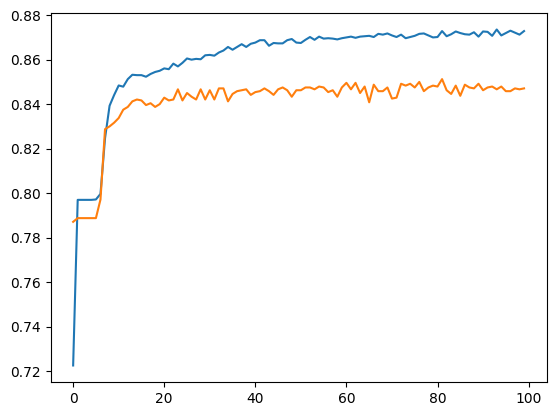

In [392]:
sns.lineplot(histry.history['accuracy'])
sns.lineplot(histry.history['val_accuracy'])

<Axes: >

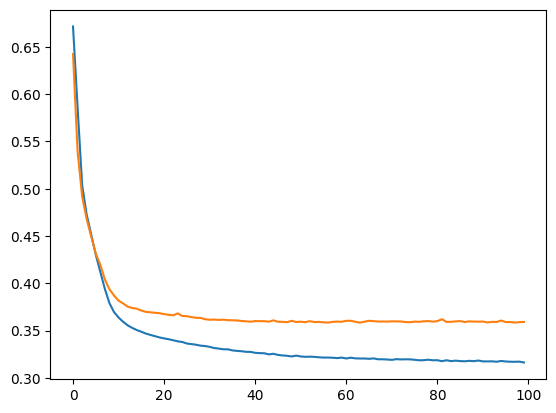

In [393]:
sns.lineplot(histry.history['loss'])
sns.lineplot(histry.history['val_loss'])

In [394]:
data = x_test.reset_index(drop=True)
train_scaled = scaled.transform(data[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']])

a = pd.DataFrame(train_scaled, columns=scaled.get_feature_names_out())

b = data.drop(columns=a.columns)

ready_test_data = pd.concat([a,b], axis = 1)
ready_test_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.577496,-0.655786,-0.695393,0.329937,0.808436,-1.019605,0,0,0,1,0,0,1
1,-0.297297,0.390011,-1.389442,-1.218471,0.808436,0.798883,1,1,1,0,0,0,1
2,-0.525607,0.485083,-0.348369,-1.218471,0.808436,-0.727980,1,0,0,0,1,1,0
3,-1.511492,1.911170,1.039728,0.689272,0.808436,1.221387,1,1,0,1,0,0,1
4,-0.951094,-1.131148,0.692704,0.782839,-0.916688,0.247560,1,1,0,0,1,1,0


In [432]:
a = model.predict(ready_test_data)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step


In [434]:
a

array([[0.07079098],
       [0.02003716],
       [0.11085786],
       ...,
       [0.82533586],
       [0.10370494],
       [0.28798115]], shape=(2000, 1), dtype=float32)

In [397]:
from sklearn.metrics import roc_auc_score, roc_curve

In [399]:
fpr, tpr, threshold = roc_curve(y_test, a)

np.float64(inf)

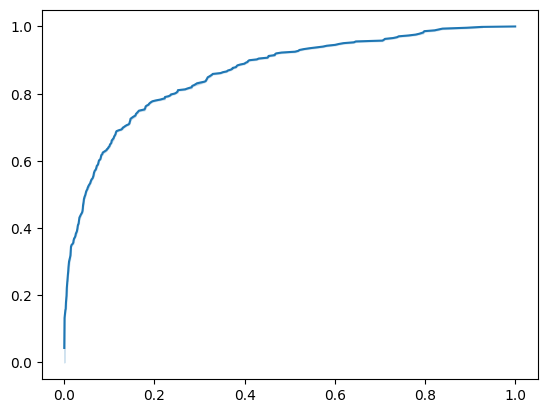

In [408]:
sns.lineplot(x= fpr, y=tpr)


In [403]:
aa = roc_auc_score(y_test, a)

In [404]:
aa

0.8630356059922318

In [414]:
li = []
for i in range(len(threshold)):
    li.append(tpr[i]-fpr[i])
thre = max(li)

In [450]:
for i in range(len(a)):
    if a[i, 0] < thre:
        a[i, 0] = 1
    else:
        a[i, 0] = 0

print(a)

[[0.]
 [0.]
 [0.]
 ...
 [1.]
 [0.]
 [0.]]


In [451]:
confusion_matrix(y_test, a)

array([[1553,   54],
       [ 223,  170]])

In [452]:
f1_score(y_test, a)

0.5510534846029174